# EEG Rhythms & Complexity

This notebook explores EEG rhythmic activity and signal complexity during deep sleep.

Goals:
- Visualize canonical EEG frequency bands
- Estimate spectral slope (1/f dynamics)
- Compute Lempel-Ziv complexity
- Compare signatures of reduced consciousness

In [1]:
import mne
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import linregress
import antropy as ant

In [4]:
raw = mne.io.read_raw_brainvision(
    "C:\\Users\\Lenovo\\Desktop\\data_prjcts\\different-paths-to-unresponsiveness\\data\\raw\\sleep_data\\sub_23\\eeg\\sub-23_task-sleep_run-3_eeg.vhdr",
    preload=True
)

Extracting parameters from C:\Users\Lenovo\Desktop\data_prjcts\different-paths-to-unresponsiveness\data\raw\sleep_data\sub_23\eeg\sub-23_task-sleep_run-3_eeg.vhdr...
Setting channel info structure...
Reading 0 ... 4601199  =      0.000 ...   920.240 secs...


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_25016\2673189468.py:1: RuntimeWarning: Channels contain different highpass filters. Lowest (weakest) filter setting (0.00 Hz) will be stored.
  raw = mne.io.read_raw_brainvision(


In [7]:
eeg_channels = mne.pick_types(
    raw.info,
    eeg=True
)

filtered = raw.copy().filter(
    0.5,
    45,
    picks=eeg_channels
)

ValueError: No appropriate channels found for the given picks (array([], dtype=int64))

In [8]:
raw.ch_names

['Fp1',
 'Fp2',
 'F3',
 'F4',
 'C3',
 'C4',
 'P3',
 'P4',
 'O1',
 'O2',
 'F7',
 'F8',
 'T7',
 'T8',
 'P7',
 'P8',
 'Fz',
 'Cz',
 'Pz',
 'Oz',
 'FC1',
 'FC2',
 'CP1',
 'CP2',
 'FC5',
 'FC6',
 'CP5',
 'CP6',
 'TP9',
 'TP10',
 'EOG',
 'ECG']

In [9]:
raw.get_channel_types()

['misc',
 'misc',
 'misc',
 'misc',
 'misc',
 'misc',
 'misc',
 'misc',
 'misc',
 'misc',
 'misc',
 'misc',
 'misc',
 'misc',
 'misc',
 'misc',
 'misc',
 'misc',
 'misc',
 'misc',
 'misc',
 'misc',
 'misc',
 'misc',
 'misc',
 'misc',
 'misc',
 'misc',
 'misc',
 'misc',
 'misc',
 'misc']

In [10]:
channel_types = {
    ch: "eeg" for ch in raw.ch_names
}

channel_types["EOG"] = "eog"
channel_types["ECG"] = "ecg"

raw.set_channel_types(channel_types)

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_25016\3843225156.py:8: RuntimeWarning: The unit for channel(s) C3, C4, CP1, CP2, CP5, CP6, Cz, ECG, EOG, F3, F4, F7, F8, FC1, FC2, FC5, FC6, Fp1, Fp2, Fz, O1, O2, Oz, P3, P4, P7, P8, Pz, T7, T8, TP10, TP9 has changed from NA to V.
  raw.set_channel_types(channel_types)


<RawBrainVision | sub-23_task-sleep_run-3_eeg.eeg, 32 x 4601200 (920.2 s), ~1.10 GiB, data loaded>

In [11]:
raw.get_channel_types()

['eeg',
 'eeg',
 'eeg',
 'eeg',
 'eeg',
 'eeg',
 'eeg',
 'eeg',
 'eeg',
 'eeg',
 'eeg',
 'eeg',
 'eeg',
 'eeg',
 'eeg',
 'eeg',
 'eeg',
 'eeg',
 'eeg',
 'eeg',
 'eeg',
 'eeg',
 'eeg',
 'eeg',
 'eeg',
 'eeg',
 'eeg',
 'eeg',
 'eeg',
 'eeg',
 'eog',
 'ecg']

In [12]:
eeg_channels = mne.pick_types(
    raw.info,
    eeg=True
)

filtered = raw.copy().filter(
    0.5,
    45,
    picks=eeg_channels
)

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.5 - 45 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.50
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 0.25 Hz)
- Upper passband edge: 45.00 Hz
- Upper transition bandwidth: 11.25 Hz (-6 dB cutoff frequency: 50.62 Hz)
- Filter length: 33001 samples (6.600 s)



Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.5 - 4 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.50
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 0.25 Hz)
- Upper passband edge: 4.00 Hz
- Upper transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 5.00 Hz)
- Filter length: 33001 samples (6.600 s)

Using matplotlib as 2D backend.


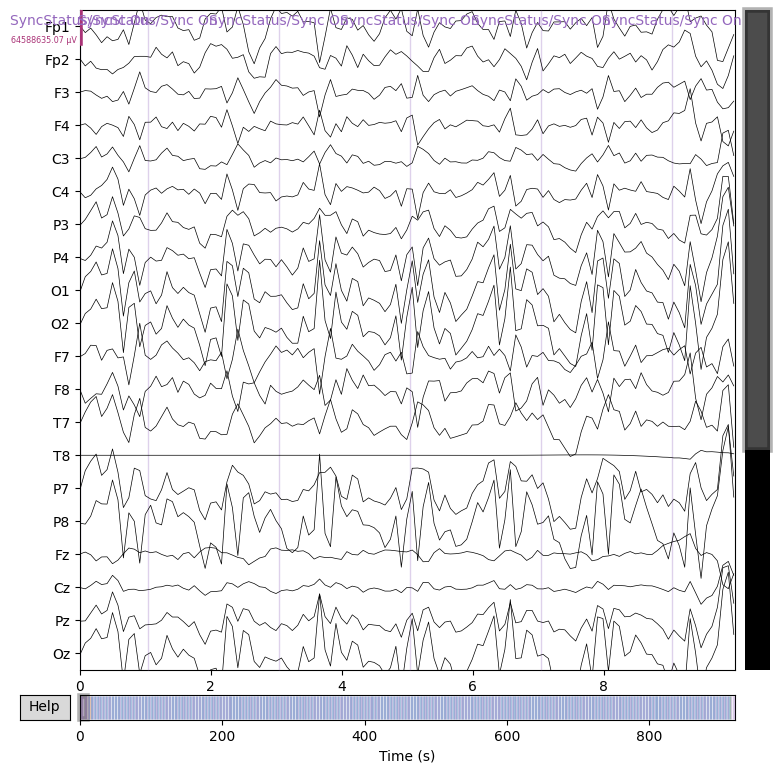

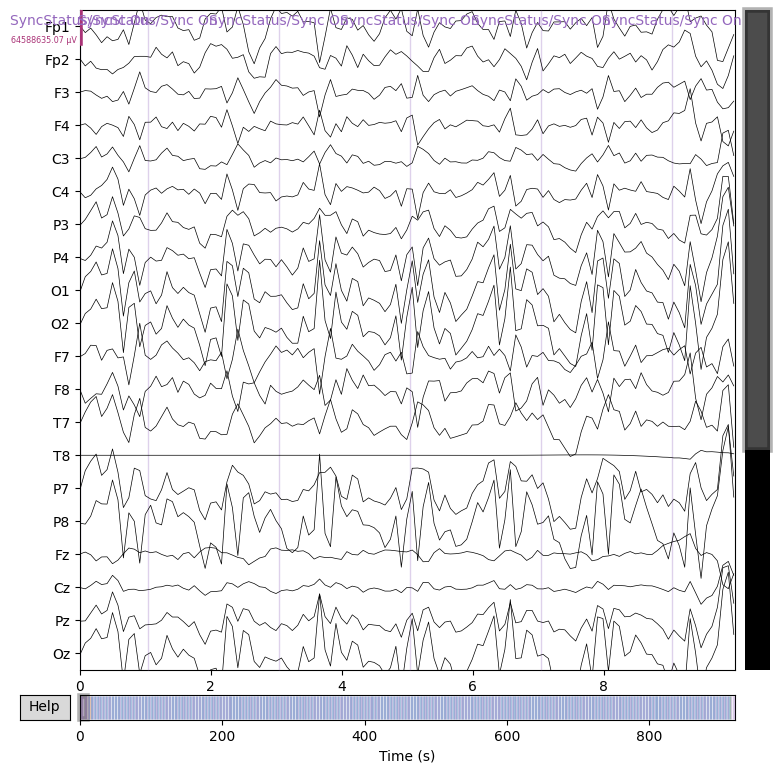

In [13]:
delta = filtered.copy().filter(
    0.5,
    4,
    picks=eeg_channels
)

delta.plot(
    duration=10,
    picks=eeg_channels,
    scalings='auto'
)

plt.show()